In [1]:
# from numba import cuda
import paicos as pa
import numpy as np
import cupy as cp
import turbocluster as tc
import math
from numba import cuda
import nvtx
import finufft

pa.settings.strict_units = False
# A snapshot object
# snap = pa.Snapshot(pa.data_dir, 247)
# snap = pa.Snapshot('/lustre/astro/berlok/zoom-simulations-new-ics/halo_0003/adiabatic-mhd/zoom4_ics_v1/output', 247)
# snap = pa.Snapshot('/lustre/astro/berlok/zoom-simulations-new-ics/halo_0003/tng/zoom12_ics_v1/output', 247)
# snap = pa.Snapshot('/scratch/lperrone/zoom-simulations-new-ics/halo_0003/tng/zoom12_ics_v1/output', 247)
snap = pa.Snapshot('/llust21/cosmo-plasm/zoom-simulations-arepo2/halo_0003/tng/zoom12/output', 
                   305, basename='snapshot')
center = snap.Cat.Group['GroupPos'][0]
widths = np.array([2e2, 2e2, 2e2], dtype=float)

widths_slicer = widths.copy()
widths_slicer[2] = 0.
center_slicer = center.copy
slicer = pa.Slicer(snap, center_slicer, widths_slicer, 'z', npix=2048)
extent = slicer.centered_extent.to('Mpc')

# m_filter = 1000*snap.mass
# filter_length = (np.cbrt(3*m_filter/(4*np.pi*snap['0_Density']))).arepo
# filter_length = 2.0*snap['0_Diameters']
# weight='0_Volume'
# filter_type = 'gaussian'





The default number of OpenMP threads, 8, exceeds the 1 available on your system. Setting numthreads=1. You can set numthreads with e.g. the command
 paicos.set_numthreads(16)


Attempting to get derived variable: 0_Volume...	[DONE]



In [2]:
import cmasher as cmr
%matplotlib widget
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize

gray = plt.cm.gray(np.linspace(0,1,10))
reds = plt.cm.Reds_r(np.linspace(0,1,10))

# plt.rc('font', family='serif')
# plt.rcParams['font.serif'] = 'ITC Bookman'
plt.rcParams['font.size'] = 16
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['lines.linewidth'] = 1.7
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['xtick.labelsize']= 14
plt.rcParams['ytick.labelsize']= 14
plt.rcParams['xtick.minor.size']= 4.0
plt.rcParams['ytick.minor.size']= 4.0
plt.rcParams['xtick.major.size']= 5.0
plt.rcParams['ytick.major.size']= 5.0
plt.rcParams['xtick.minor.width']= 0.7
plt.rcParams['ytick.minor.width']= 0.7
plt.rcParams['xtick.major.width']= 1.
plt.rcParams['ytick.major.width']= 1.

plt.rcParams['xtick.direction']= 'in'
plt.rcParams['ytick.direction']= 'in'

## These are unfortunately copies of the base code 

In [3]:
@cuda.jit(device=True, inline=True)
def distance(pos, pos_other):
    dist = math.sqrt((pos[0] - pos_other[0])**2 +
                     (pos[1] - pos_other[1])**2 +
                     (pos[2] - pos_other[2])**2)
    return dist


@cuda.jit(device=True, inline=True)
def gaussian_kernel(dist, filter_length):

    weight = math.exp(-0.5*(dist/filter_length)**2)/filter_length**3/(2.0*np.pi)**(3./2.)
    # weight = math.exp(-0.5*(dist/filter_length)**2)/filter_length/(2.0*np.pi)**(1./2.)

    return weight

@cuda.jit(device=True, inline=True)
def mexican_kernel(dist, filter_length):

    weight = (3 - (dist/filter_length)**2)*math.exp(-0.5*(dist/filter_length)**2)/filter_length**3/(2.0*np.pi)**(3./2.)
    # weight = math.exp(-0.5*(dist/filter_length)**2)/filter_length/(2.0*np.pi)**(1./2.)

    return weight

@cuda.jit(device=True, inline=True)
def check_distance(ip_tile_x, ip_tile_y, ip_tile_z,
                   tile_x, tile_y, tile_z,
                   delta_x, delta_y, delta_z,
                   tile_widths, filter_length):

    overlap = False

    xcoord_edge = delta_x
    if (tile_x > ip_tile_x):
        xcoord_edge = tile_widths[0] * (tile_x - ip_tile_x - 0.5)
    elif (tile_x < ip_tile_x):
        xcoord_edge = tile_widths[0] * (tile_x - ip_tile_x + 0.5)

    ycoord_edge = delta_y
    if (tile_y > ip_tile_y):
        ycoord_edge = tile_widths[1] * (tile_y - ip_tile_y - 0.5)
    elif (tile_y < ip_tile_y):
        ycoord_edge = tile_widths[1] * (tile_y - ip_tile_y + 0.5)

    zcoord_edge = delta_z
    if (tile_z > ip_tile_z):
        zcoord_edge = tile_widths[2] * (tile_z - ip_tile_z - 0.5)
    elif (tile_z < ip_tile_z):
        zcoord_edge = tile_widths[2] * (tile_z - ip_tile_z + 0.5)
        
    dist2 = (delta_x - xcoord_edge)**2 + \
            (delta_y - ycoord_edge)**2 + \
            (delta_z - zcoord_edge)**2

    filt2 = filter_length**2
    if (filt2 >= dist2):
        overlap = True
    
    return overlap



@cuda.jit()
def check_particle(pos, hsml, center, widths, isParticleInDomain):
    """
    """
    ip = cuda.grid(1)
    # each thread is assigned to a particle
    numParticles = pos.shape[0]
    isParticleInDomainTmp = 0

    if (ip < numParticles):

        xp, yp, zp = pos[ip]
        xmin = center[0] - widths[0] / 2 - hsml[ip]
        xmax = center[0] + widths[0] / 2 + hsml[ip]

        ymin = center[1] - widths[1] / 2 - hsml[ip]
        ymax = center[1] + widths[1] / 2 + hsml[ip]

        zmin = center[2] - widths[2] / 2 - hsml[ip]
        zmax = center[2] + widths[2] / 2 + hsml[ip]

        if (xp > xmin) and (xp < xmax):
            if (yp > ymin) and (yp < ymax):
                if (zp > zmin) and (zp < zmax):
                    isParticleInDomainTmp = 1


        isParticleInDomain[ip] = isParticleInDomainTmp

@cuda.jit()
def compactify_particles(pos, tile_index, cumulative_occupancy_flat, isParticleInDomain,
                         oldIndex):
    """
    """
    ip = cuda.grid(1)
    numParticles = pos.shape[0]
    # each thread takes care of a particle
    if (ip < numParticles):
        newPos = int(cumulative_occupancy_flat[ip])
        if (isParticleInDomain[ip] > 0):
            oldIndex[newPos - 1] = ip



# This is where you can play with the kernel parameters

In [4]:
@cuda.jit()
def apply_filter_optimized_test(oldIndex, pos, hsml, tile_index, 
                     start_index_for_tile, particles_per_tile, tile_widths,
                     variable, weights, offsets, npixs, center, widths, filter_lengths, 
                     smooth_var, filter_type, hitsNeighbours, isParticleInDomain, 
                     iterativeFilter, hasConverged, numIterations, filter_lengths_out, mu_l):
    """
    filter_lengths is an array of size pos.shape([0])
    type can be "mean" or "gaussian"
    """
    # threadindex
    ip = cuda.grid(1)

    if (ip < oldIndex.shape[0]):
        oldIp = oldIndex[ip]
    
        # particle position
        xp = pos[oldIp, 0]
        yp = pos[oldIp, 1]
        zp = pos[oldIp, 2]

        VarRegister = variable[oldIp]

        if (iterativeFilter == 0): # no iterative
            filter_length = filter_lengths[oldIp]
        else: #iterative
            filter_length = 0.3 * filter_lengths[oldIp] 
            
            # # iterative scheme ~Vazza+2012 
            # # filter length is gradually increased
            # filter_length = 0.1 * filter_lengths[oldIp] 
            #  # let's start from 30% of the filter_length or 5 x hsml, whichever is largest
            # if (0.1 * filter_lengths[oldIp] < 2.0 * hsml[oldIp]):  
            #     filter_length = 2.0 * hsml[oldIp] 
           
            
        filterIncrease = 1.*hsml[oldIp] # it is additive factor (?)
        max_filter_length = 5.0*filter_lengths[oldIp] 
        # need to make sure that with max_filter_length it does not go
        # beyond region loaded on GPU
        
        hasIterationConverged = False
    
        turbFieldOld = 0.0
        turbFieldNew = 0.0
        toleranceParam = 0.05
        muOld = 0.0
    
        numInteractingPartOld = 0
        numInteractingPartNew = 0
        

        ip_tile_x = tile_index[oldIp, 0]
        ip_tile_y = tile_index[oldIp, 1]
        ip_tile_z = tile_index[oldIp, 2]
    
        # relative coordinates w.r.t. center of tile
        delta_x = xp - offsets[0] - (ip_tile_x + 0.5) * tile_widths[0] 
        delta_y = yp - offsets[1] - (ip_tile_y + 0.5) * tile_widths[1] 
        delta_z = zp - offsets[2] - (ip_tile_z + 0.5) * tile_widths[2] 
    
        filter_window = 1
        # for gaussian filter the sigma is  1/4 of the
        # filter_length of the source particle
        if filter_type == 1:
            filter_window = 4

        numIter = 0
        while (filter_length <= max_filter_length and not hasIterationConverged):
            # the idea is to use this while loop both for iterative and non-iterative case
            # if non-iterative we exit after one go
            
            smoothVarRegister = 0.0
            smoothVarSqRegister = 0.0
            weight = 0.0
            weight_tmp = 0.0
            numInteractingPartNew = 0

            ####################################
            # code to check what are the tiles that can overlap
            # with the particle filter_length
            ####################################

            
            ip_tile_x_min = ip_tile_x - (- delta_x + \
                            filter_length + tile_widths[0] / 2) // tile_widths[0] 
            ip_tile_x_max = ip_tile_x + (delta_x +   \
                            filter_length + tile_widths[0] / 2) // tile_widths[0] 
        
            ip_tile_y_min = ip_tile_y - (- delta_y + \
                            filter_length + tile_widths[1] / 2) // tile_widths[1] 
            ip_tile_y_max = ip_tile_y + (delta_y +   \
                            filter_length + tile_widths[1] / 2) // tile_widths[1] 
        
            ip_tile_z_min = ip_tile_z - (- delta_z + \
                            filter_length + tile_widths[2] / 2) // tile_widths[2] 
            ip_tile_z_max = ip_tile_z + (delta_z +   \
                            filter_length + tile_widths[2] / 2) // tile_widths[2] 

            ####################################
            # end of code to check overlap
            ####################################
            
            if filter_type == 0:
                for tile_x in range(ip_tile_x_min, ip_tile_x_max + 1):
                    for tile_y in range(ip_tile_y_min, ip_tile_y_max + 1):
                        for tile_z in range(ip_tile_z_min, ip_tile_z_max + 1):
                            if check_distance(ip_tile_x, ip_tile_y, ip_tile_z,
                                              tile_x, tile_y, tile_z,
                                              delta_x, delta_y, delta_z,
                                              tile_widths, filter_length):
    
                                start_index = start_index_for_tile[tile_x,
                                                                   tile_y, tile_z]
                                n_particles = particles_per_tile[tile_x,
                                                                 tile_y, tile_z]
            
                                for ip_other in range(start_index, start_index + n_particles):
                                    dist = distance((xp, yp, zp), pos[ip_other])
                                    if dist < filter_length:
                                        weight_tmp = 1.0 * weights[ip_other]
                                        weight += weight_tmp
                                        smoothVarRegister += variable[ip_other] * weight_tmp
                                        smoothVarSqRegister += variable[ip_other]**2 * weight_tmp
                                        numInteractingPartNew += 1
        
            elif filter_type == 1:
                for tile_x in range(ip_tile_x_min, ip_tile_x_max + 1):
                    for tile_y in range(ip_tile_y_min, ip_tile_y_max + 1):
                        for tile_z in range(ip_tile_z_min, ip_tile_z_max + 1):
                            if check_distance(ip_tile_x, ip_tile_y, ip_tile_z,
                                              tile_x, tile_y, tile_z,
                                              delta_x, delta_y, delta_z,
                                              tile_widths, filter_length):
                                start_index = start_index_for_tile[tile_x,
                                                                   tile_y, tile_z]
                                n_particles = particles_per_tile[tile_x,
                                                                 tile_y, tile_z]
            
                                for ip_other in range(start_index, start_index + n_particles):
                                    dist = distance((xp, yp, zp), pos[ip_other])
                                    if dist < filter_length:

                                        gaussian_weight = gaussian_kernel(dist, filter_length / filter_window)
                                        weight += weights[ip_other] * gaussian_weight
                                        smoothVarRegister += variable[ip_other] * gaussian_weight * \
                                                            weights[ip_other]
                                        smoothVarSqRegister += variable[ip_other]**2 * gaussian_weight * \
                                                            weights[ip_other]
                                        
                                        numInteractingPartNew += 1
            
            if weight > 0.:
                smoothVarRegister /= weight
                smoothVarSqRegister /= weight

            mu = smoothVarSqRegister - smoothVarRegister**2

            ################################
            # part to check convergence of iterative filter
            ################################
            
            if (iterativeFilter == 0): # no iterative
                hasIterationConverged = True
            else: # iterative
                turbFieldNew = VarRegister - smoothVarRegister
                increase =  math.fabs(turbFieldNew - turbFieldOld) 
                # mexican_mu = math.fabs(mexicanVarSq - mexicanVar**2)
                delta_mu = math.fabs(mu - muOld)
                # we declare the iteration converged when all the following are satisfied:
                # 1. the relative increase is less than the tolerance
                # 2. we have done at least one iteration (so we can compare old and new)
                # 3. the number of particles at the new iteration has increased
                # (if the number did not increase this would naturally cause 1. to be true)
                # 4. the number of particles it interacts with is > 8 (2 per dim, arbitrary)

                # this is the convergence criterion a la Vazza
                if (numIter > 1) and (increase <= toleranceParam * (0.0 + math.fabs(turbFieldOld))):
                # these below are other possibilities...
                # if (numIter > 1) and (mexican_mu <= (filter_length / filterIncrease)**1.5 * \
                #                       1.0 * mu):
                # if (numIter > 1) and (mexican_mu <= mu):
                # if (numIter > 1) and (delta_mu <= (filterIncrease / filter_length) * mu):
                    if (numInteractingPartNew > numInteractingPartOld):
                        if (numInteractingPartNew > 8):
                            hasIterationConverged = True
                            hasConverged[oldIp] = 1
                else: # not converged
                    filter_length += filterIncrease
                    turbFieldOld = turbFieldNew
                    muOld = mu
                    numIter += 1
                    numInteractingPartOld = numInteractingPartNew

            ################################
            # end of check convergence of iterative filter
            ################################

        smooth_var[oldIp] = smoothVarRegister
        hitsNeighbours[oldIp] = numInteractingPartNew
        mu_l[oldIp] = mu
        
        if (iterativeFilter == 1): # iterative
            filter_lengths_out[oldIp] = filter_length
            numIterations[oldIp] = numIter
            
            if not hasIterationConverged:
                # this is to adjust for the last iteration
                filter_lengths_out[oldIp] -= filterIncrease
                numIterations[oldIp] -= 1
                

## Here is class Thomas defined

In [5]:
class Thomas(tc.SmoothingFilter):
    def filter_variable(self, variable, filter_length, weight=None, filter_type="mean", iterative=False,
                       shared_mem=False, Nmax=64, optimized=False):
        """
        shared_mem has been tested only with filter_type="mean"
        Nmax is the max number of particles per block. Each tile is split
        in "logic" blocks with Nmax particles max (can be less, but not zero)
        and assigned to exactly 1 block of threads with Nmax threads
        """

        if (shared_mem and optimized):
            raise RuntimeError('shared_mem and optimized are incompatible')
        if (shared_mem and iterative):
            raise RuntimeError('shared_mem and iterative are incompatible')
            
        rng0 = nvtx.start_range(message="do_filter")
        
        variable_str, unit_quantity = self._send_variable_to_gpu(variable)

        if weight is not None:
            if isinstance(weight, str):
                self._send_variable_to_gpu(weight)
            else:
                raise RuntimeError('has to be a string')

        # send filter_length to gpu
        if isinstance(filter_length, np.ndarray):
            assert filter_length.shape[0] == self.index.shape[0]
            if (np.max(filter_length[self.indicesFirstPass]) > self.max_search_radius):
                raise RuntimeError('The chosen filter length is larger than the \
                maximum search radius. This would cause searching for cells that \
                have not been moved to the GPU. To solve this decrease \
                the filter length or increase the search radius accordingly')
            self._send_variable_to_gpu(filter_length, gpu_key='filter_lengths')
        else:
            if (filter_length > self.max_search_radius):
                raise RuntimeError('The chosen filter length is larger than the \
                maximum search radius. This would cause searching for cells that \
                have not been moved to the GPU. To solve this decrease \
                the filter length or increase the search radius accordingly')
            self.gpu_variables['filter_lengths'] = cp.ones(self.Np) * filter_length

        # Do the filtering
        if not shared_mem:
            if optimized:
                smooth_variable = self._apply_filter_gpu_optimized(variable_str, weight, filter_type, iterative)
            else: 
                smooth_variable = self._apply_filter_gpu(variable_str, weight, filter_type, iterative)
        else:
            smooth_variable = self._apply_filter_gpu_shared(variable_str, weight, filter_type, Nmax)

        if unit_quantity is not None:
            smooth_variable = smooth_variable * unit_quantity

        nvtx.end_range(rng0)
        
        return smooth_variable

    
    def _apply_filter_gpu_optimized(self, variable_str, weight, filter_type, iterative):
        """
        The idea behind this 'optimized' version is to check if the particle
        is in the domain _beforehand_, and then run the filtering kernel 
        only on those that are in the domain. There is a certain speedup 
        in doing so (for small-size problems running time can be 1/3)
        I have also improved the tile searching within the kernel: now only
        the tiles that *overlap* with the filtering radius of each particle
        are selected, without wasting time looping over those that do not
        For now I am adding it as an option to the filter_variable function
        (optimized=True) to allow a comparison with the baseline 
        (optimized=False)
        """

        if self.spherical:
            raise RuntimeError('optimized filter has only \
                                been tested with cartesian grids')
            
        pos = self.gpu_variables['pos']
        hsml = self.gpu_variables['hsml']
        # - self.tile.off_sets[None,:]
        tile_index = self.tile.tile_index
        start_index_for_tile = self.tile.start_index_for_tile
        particles_per_tile = self.tile.particles_per_tile
        tile_widths = self.tile.tile_widths
        variable = self.gpu_variables[variable_str]
        npixs = self.tile.npixs
        center = self.gpu_variables['center']
        widths = self.gpu_variables['widths']
        offsets = self.tile.off_sets
        filter_lengths = self.gpu_variables['filter_lengths']
        if filter_type == "mean":
            filter_type = 0
        elif filter_type == "gaussian":
            filter_type = 1

        iterativeFilter = 0 # not iterative
        if iterative:
            iterativeFilter = 1 # iterative
        

        if cp.max(filter_lengths) > self.extra_layer_thickness_value:
            err_msg = f"{cp.max(filter_lengths)} is larger than {self.extra_layer_thickness}"
            raise RuntimeError(err_msg)

        if weight is not None:
            weights = self.gpu_variables[weight]
        else:
            weights = cp.ones_like(variable)

        isParticleInDomain = cp.zeros(pos.shape[0])
        
        check_particle[self.blocks_1d, self.threadsperblock](pos, hsml, center, widths, isParticleInDomain)
        self.isParticleInDomain = isParticleInDomain
        cumulative_occupancy = cp.cumsum(isParticleInDomain)
        numParticlesInDomain = int(cumulative_occupancy[-1])
        oldIndex = cp.zeros(numParticlesInDomain,dtype=int)
        
        compactify_particles[self.blocks_1d, self.threadsperblock](pos, tile_index,
                                        cumulative_occupancy.flatten(), isParticleInDomain, 
                                        oldIndex)
        self.oldIndex = oldIndex
        
        blocks_1d = (numParticlesInDomain + (self.threadsperblock - 1)) // self.threadsperblock
        
        smooth_var = cp.zeros_like(variable)
        hitsNeighbours = cp.zeros(variable.shape,dtype="int")
        # isParticleInDomain = cp.zeros(variable.shape,dtype="int")
        hasConverged = cp.zeros(variable.shape,dtype="int")
        numIterations = cp.zeros(variable.shape,dtype="int")
        filter_lengths_out = cp.zeros(variable.shape,dtype="float")
        ldmudl_out = cp.zeros(variable.shape,dtype="float")

        rng = nvtx.start_range(message="cartesian filter (optimized)")
        apply_filter_optimized_test[blocks_1d, self.threadsperblock](oldIndex, pos, hsml, tile_index, 
                                                          start_index_for_tile, particles_per_tile, tile_widths,
                                                           variable, weights, offsets, npixs, center, widths, 
                                                          filter_lengths, smooth_var, filter_type, hitsNeighbours,
                                                              isParticleInDomain, iterativeFilter, hasConverged, 
                                                               numIterations, filter_lengths_out, ldmudl_out)
        nvtx.end_range(rng)

        self.hitsNeighbours = hitsNeighbours
        self.hitsNeighboursUnSorted = hitsNeighbours[self.tile.unsort_index]
        self.isParticleInDomainUnSorted = isParticleInDomain[self.tile.unsort_index]
        
        if iterative:
            self.filter_lengths_out = filter_lengths_out[self.tile.unsort_index]
            self.ldmudl_out = ldmudl_out[self.tile.unsort_index]
            self.hasConvergedUnSorted = hasConverged[self.tile.unsort_index]
            self.numIterationsUnSorted = numIterations[self.tile.unsort_index]
            tot_particles_domain = np.sum(self.isParticleInDomainUnSorted)
            num_part_converg = np.sum(self.hasConvergedUnSorted[self.isParticleInDomainUnSorted>0])
            percent_converg = num_part_converg/tot_particles_domain
            print("%.2f percent of particles (%d / %d) has converged"%(percent_converg*100,num_part_converg,tot_particles_domain))
            mean_iter = np.mean(self.numIterationsUnSorted[self.isParticleInDomainUnSorted>0])
            std_iter = np.std(self.numIterationsUnSorted[self.isParticleInDomainUnSorted>0])
            print("Number iterations needed: %.2f (+/- %.2f)"%(mean_iter,std_iter))
            print("Min/Max iterations needed: %d / %d"%(np.min(self.numIterationsUnSorted[self.isParticleInDomainUnSorted>0]),
                                                        np.max(self.numIterationsUnSorted[self.isParticleInDomainUnSorted>0])))
            
        
        
        return cp.asnumpy(smooth_var[self.tile.unsort_index])
      

In [6]:
# simple volume average function over the computational volume

def volume_avg(snap, sf, qt):
    if isinstance(qt, str):
        qt = snap[qt]
        
    a = np.sum((qt*snap['0_Volume'])[sf.indicesFirstPass])
    vol = np.sum((snap['0_Volume'])[sf.indicesFirstPass])
    return a/vol

In [7]:
Gauss = snap.uq('G')
arepo_length = snap['0_Diameters'].uq
density_unit = snap['0_Density'].uq
arepo_length_in_Mpc = arepo_length.to('Mpc').value
kpc = snap.uq('kpc')

Attempting to get derived variable: 0_Diameters...	[DONE]



In [8]:
# from paicos import units as pu
# from astropy import units as u

weight = '0_Volume'
filter_type = 'gaussian'



In [16]:
def make_density_plot(slicer, snap, sf, n, suffix=''):

    RHO = slicer.slice_variable(snap['0_Density'])
    RHO_turb = slicer.slice_variable(snap['turbrho'+suffix])
    RHO_smooth = slicer.slice_variable(snap['smoothrho'+suffix])
    
    vmin = RHO.value.min()
    vmax = RHO.value.max()
    norm0 = Normalize(vmin=vmin,vmax=vmax)
    
    # vmin = -0.6
    vmax = RHO_turb.value.max()
    norm1 = Normalize(vmin=-vmax,vmax=vmax)
    
    # cmap = cmr.fall
    
    # cmap0 = cmr.rainforest
    cmap1 = cmr.prinsenvlag_r
    cmap0 = cmr.eclipse
    
    fig, axes = plt.subplots(1,3, figsize=(8,7),sharex=True, sharey=True)
    
    im00 = axes[0].imshow(
        RHO.value, origin='lower', cmap=cmap0, norm=norm0, extent=extent.value)
    im01 = axes[1].imshow(
        RHO_turb.value, origin='lower', cmap=cmap1, norm=norm1, extent=extent.value)
    im02 = axes[2].imshow(
        RHO_smooth.value, origin='lower', cmap=cmap0, norm=norm0, extent=extent.value)
    
    axes[0].set_title(r'$\rho$')
    axes[1].set_title(r'$\delta \rho$')
    axes[2].set_title(r'$\langle \rho \rangle_l$')
    
    
    for i in range(3):
        axes[i].set_xlabel(extent.label('x'))
    
    axes[0].set_ylabel(extent.label('y'))
    
    cbar00 = fig.colorbar(im00, orientation='horizontal',shrink=0.95)
    cbar00.set_label(RHO.label('\\rho'),fontsize=12)
    
    cbar01 = fig.colorbar(im01, orientation='horizontal',shrink=0.95)
    cbar01.set_label(RHO_turb.label('\\delta \\rho'),fontsize=12)
    
    cbar02 = fig.colorbar(im02, orientation='horizontal',shrink=0.95)
    cbar02.set_label(RHO_smooth.label('\\langle \\rho \\rangle_l'),fontsize=12)
    
    
    fig.subplots_adjust(top=0.9,
    bottom=0.05,
    left=0.1,
    right=0.95,
    hspace=0.15,
    wspace=0.00)
    
    fig.suptitle('Turbulent density field (iterative) snap=%04d'%(n),y=0.98)
    # plt.savefig('./Plots/Loop/1.density_iterative_filter_%04d.pdf'%(n), dpi=400)
    
    plt.show()
    # plt.close()


## Now do loop

Now doing snapshot n = 304
Attempting to get derived variable: 0_Volume...	[DONE]

Attempting to get derived variable: 0_Diameters...	[DONE]

100.00 percent of particles (565913 / 565913) has converged
min/max/avg occupancy cartesian tiling 0 / 6 / 0.28


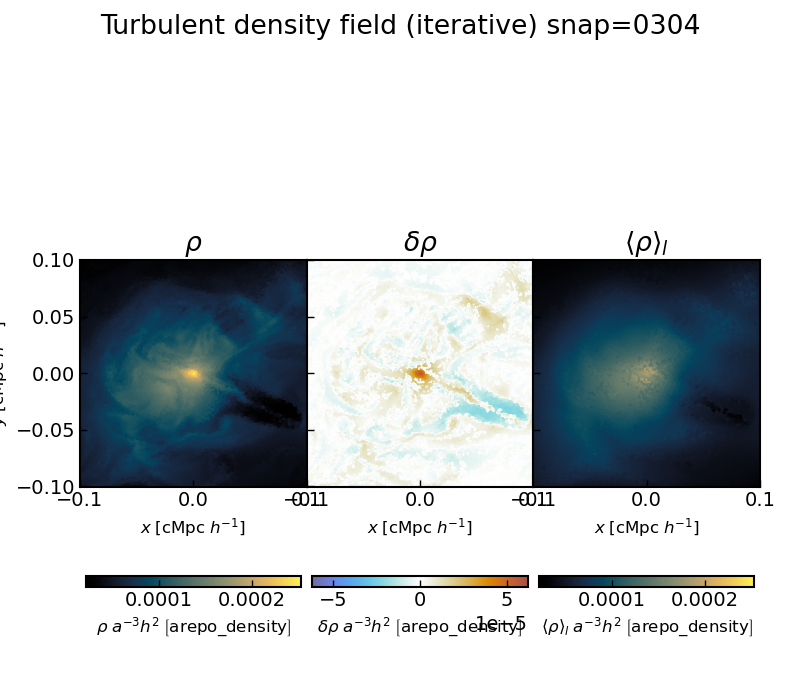

99.98 percent of particles (565803 / 565913) has converged
Number iterations needed: 10.17 (+/- 8.55)
Min/Max iterations needed: 2 / 70
min/max/avg occupancy cartesian tiling 0 / 6 / 0.28


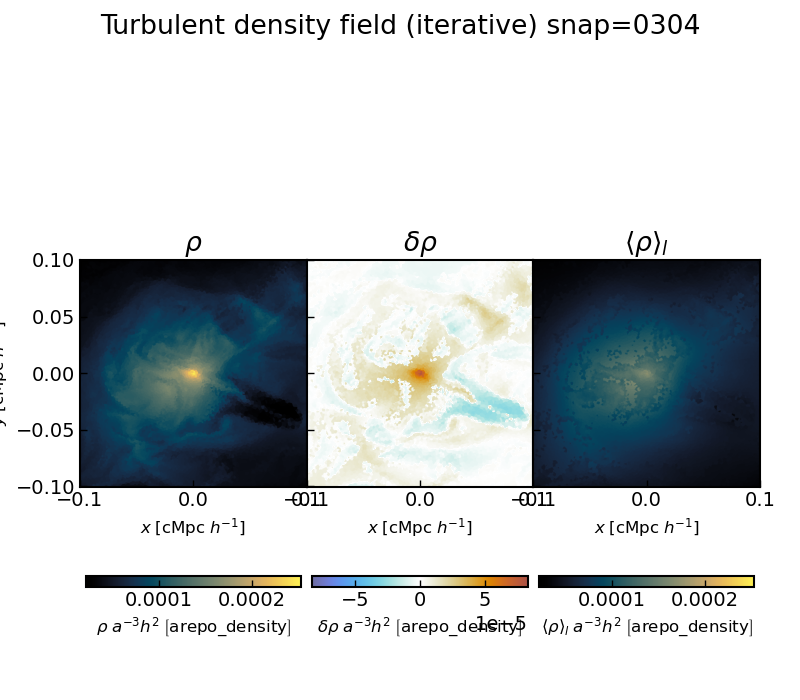

In [19]:
# for n in range(len(snapshot_list)):
for n in range(304,305):
    print("Now doing snapshot n = %d"%(n))
    snap = pa.Snapshot('/llust21/cosmo-plasm/zoom-simulations-arepo2/halo_0003/tng/zoom12/output', 
                   n, basename='snapshot')
    center = snap.Cat.Group['GroupPos'][0]
    widths = np.array([2e2, 2e2, 2e2], dtype=float)
    
    widths_slicer = widths.copy()
    widths_slicer[2] = 0.
    center_slicer = center.copy
    slicer = pa.Slicer(snap, center_slicer, widths_slicer, 'z', npix=2048)
    extent = slicer.centered_extent.to('Mpc')

    # remember that when gaussian the actual kernel size is 1/4 of the filter length, so here
    # l is 5*arepo_length
    filter_length = 4*10*np.ones(snap['0_Diameters'].shape)*arepo_length
    

    # when using the iterative filter we need to make sure that the particles required are
    # loaded on the GPU. This can be achieved by increasing the search_radius
    # to be larger than the maximum filter_radius of the iterative loop
    sf = tc.SmoothingFilter(snap, center, widths, npix=256, orientation=None, 
                            search_radius=5.*filter_length.value) 

    
    snap['smoothrho'], snap['turbrho'] = tc.extract_turbulent_scalar(snap, sf, 
                                              '0_Density', filter_length, 
                                              weight, filter_type, iterative=True)
    # final_density_iter_length = sf.filter_lengths_out.get()*arepo_length

    make_density_plot(slicer, snap, sf, n, suffix='')

    # here you can do something similar for your sf_Thomas
    # when using the iterative filter we need to make sure that the particles required are
    # loaded on the GPU. This can be achieved by increasing the search_radius
    # to be larger than the maximum filter_radius of the iterative loop
    sf_Thomas = Thomas(snap, center, widths, npix=256, orientation=None, 
                            search_radius=5.*filter_length.value)
    snap['smoothrho_Thomas'], snap['turbrho_Thomas'] = tc.extract_turbulent_scalar(snap, sf_Thomas, 
                                              '0_Density', filter_length, 
                                              weight, filter_type, iterative=True)
    # final_density_iter_length_Thomas = sf_Thomas.filter_lengths_out.get()*arepo_length
    make_density_plot(slicer, snap, sf_Thomas, n, suffix='_Thomas')


In [ ]:
# these are things you can access

# iteration_converged = -1.0*np.ones(snap['0_Density'].value.shape)
# iteration_converged[sf_iter.index] = sf_iter.hasConvergedUnSorted.get()

# number_iterations = np.zeros(snap['0_Density'].value.shape)
# number_iterations[sf_iter.index] = sf_iter.numIterationsUnSorted.get()

# particles_interacted = np.zeros(snap['0_Density'].value.shape)
# particles_interacted[sf_iter.index] = sf_iter.hitsNeighboursUnSorted.get()

# final_filter_length = 0.0*filter_length.copy
# final_filter_length[sf_iter.index] = sf_iter.filter_lengths_out.get()*filter_length.unit
